# Probando cosas

In [11]:


DATASETS_DIR = "datasets"
CSV_FINAL = os.path.join(DATASETS_DIR, "replays_subset_with_time_percentages.csv")

df_model = pd.read_csv(CSV_FINAL, low_memory=False)

print("Shape del dataset final:", df_model.shape)
display(df_model.head())

Shape del dataset final: (10000, 107)


,blue.color,blue.stats.ball.possession_time,blue.stats.ball.time_in_side,blue.stats.boost.amount_collected,blue.stats.boost.amount_collected_big,blue.stats.boost.amount_collected_small,blue.stats.boost.amount_overfill,blue.stats.boost.amount_overfill_stolen,blue.stats.boost.amount_stolen,blue.stats.boost.amount_stolen_big,...,orange.stats.positioning.time_behind_ball,orange.stats.positioning.time_defensive_half,orange.stats.positioning.time_defensive_third,orange.stats.positioning.time_infront_ball,orange.stats.positioning.time_neutral_third,orange.stats.positioning.time_offensive_half,orange.stats.positioning.time_offensive_third,overtime,overtime_seconds,server.region
0,blue,44.282927,39.068293,2506,2110,396,289,30,516,369,...,162.912195,128.600000,96.702434,34.546341,57.858537,68.853659,42.887805,False,0.0,USE
1,blue,40.938907,69.038585,3835,2788,1047,588,76,663,427,...,162.025730,106.874598,66.543408,36.411576,82.903543,91.562701,48.987138,False,0.0,USE
2,blue,31.317919,43.644509,5306,3816,1490,403,32,1103,654,...,143.297688,135.034682,97.141618,56.421965,68.057803,64.684971,34.523121,False,0.0,USE
3,blue,36.722500,36.790000,4858,3752,1106,618,251,1148,868,...,150.320000,134.945000,107.170000,47.282500,55.260002,62.655000,35.170000,False,0.0,EU
4,blue,38.622642,49.783019,1281,1006,275,405,38,188,167,...,171.433962,119.905666,83.575472,26.509434,73.584906,78.037736,40.783019,False,0.0,EU


In [12]:
print("\nTipos de datos:")
print(df_model.dtypes)

print("\nNulos por columna:")
print(df_model.isna().sum().sort_values(ascending=False).head(20))

print("\nDistribucion del target:")
print(df_model["max.game.rank"].value_counts(dropna=False))


Tipos de datos:
blue.color                                           str
blue.stats.ball.possession_time                  float64
blue.stats.ball.time_in_side                     float64
blue.stats.boost.amount_collected                  int64
blue.stats.boost.amount_collected_big              int64
                                                  ...   
orange.stats.positioning.time_offensive_half     float64
orange.stats.positioning.time_offensive_third    float64
overtime                                            bool
overtime_seconds                                 float64
server.region                                        str
Length: 107, dtype: object

Nulos por columna:
blue.color                                       0
blue.stats.ball.possession_time                  0
blue.stats.ball.time_in_side                     0
blue.stats.boost.amount_collected                0
blue.stats.boost.amount_collected_big            0
blue.stats.boost.amount_collected_small          0
blu

In [13]:
target_col = "max.game.rank"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (10000, 106)
Shape de y: (10000,)


In [14]:
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Columnas categoricas:", categorical_cols)
print("Numero de categoricas:", len(categorical_cols))

print("\nNumero de numericas/booleanas:", len(numeric_cols))
print("Primeras 20 numericas:", numeric_cols[:20])

Columnas categoricas: ['blue.color', 'orange.color', 'server.region']
Numero de categoricas: 3

Numero de numericas/booleanas: 103
Primeras 20 numericas: ['blue.stats.ball.possession_time', 'blue.stats.ball.time_in_side', 'blue.stats.boost.amount_collected', 'blue.stats.boost.amount_collected_big', 'blue.stats.boost.amount_collected_small', 'blue.stats.boost.amount_overfill', 'blue.stats.boost.amount_overfill_stolen', 'blue.stats.boost.amount_stolen', 'blue.stats.boost.amount_stolen_big', 'blue.stats.boost.amount_stolen_small', 'blue.stats.boost.amount_used_while_supersonic', 'blue.stats.boost.avg_amount', 'blue.stats.boost.bcpm', 'blue.stats.boost.bpm', 'blue.stats.boost.count_collected_big', 'blue.stats.boost.count_collected_small', 'blue.stats.boost.count_stolen_big', 'blue.stats.boost.count_stolen_small', 'blue.stats.boost.time_boost_0_25', 'blue.stats.boost.time_boost_25_50']


In [15]:
class_counts = y.value_counts()
print(class_counts)

print("\nNumero de clases:", y.nunique())
print("Clase mayoritaria:", class_counts.max())
print("Clase minoritaria:", class_counts.min())
print("Imbalance ratio:", class_counts.max() / class_counts.min())

max.game.rank
Champion III          1632
Grand Champion I      1626
Champion II           1517
Grand Champion II     1505
Champion I            1202
Grand Champion III    1079
Diamond III            542
Diamond II             411
Diamond I              243
Platinum III           111
Platinum II             44
Platinum I              40
Gold III                19
Gold II                 15
Gold I                  11
Silver III               3
Name: count, dtype: int64

Numero de clases: 16
Clase mayoritaria: 1632
Clase minoritaria: 3
Imbalance ratio: 544.0


In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nDistribucion train:")
print(y_train.value_counts(normalize=True).head())

print("\nDistribucion test:")
print(y_test.value_counts(normalize=True).head())

Train shape: (8000, 106)
Test shape: (2000, 106)

Distribucion train:
max.game.rank
Champion III         0.163250
Grand Champion I     0.162625
Champion II          0.151625
Grand Champion II    0.150500
Champion I           0.120250
Name: proportion, dtype: float64

Distribucion test:
max.game.rank
Champion III         0.1630
Grand Champion I     0.1625
Champion II          0.1520
Grand Champion II    0.1505
Champion I           0.1200
Name: proportion, dtype: float64


In [17]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer, matthews_corrcoef

# =========================
# 1. CARGAR CSV FINAL
# =========================
DATASETS_DIR = "datasets"
CSV_FINAL = os.path.join(DATASETS_DIR, "replays_subset_with_time_percentages.csv")

df_model = pd.read_csv(CSV_FINAL, low_memory=False)

print("========================================")
print("Dataset cargado")
print("========================================")
print("Shape original:", df_model.shape)
display(df_model.head())

# =========================
# 2. LIMPIEZA MINIMA PARA MODELADO
# =========================
# Quitamos columnas categoricas que no aportan informacion real
cols_to_drop = ["blue.color", "orange.color"]
cols_to_drop = [c for c in cols_to_drop if c in df_model.columns]

if cols_to_drop:
    df_model = df_model.drop(columns=cols_to_drop)

print("\n========================================")
print("Columnas eliminadas antes de modelar")
print("========================================")
print(cols_to_drop if cols_to_drop else "No se elimino ninguna columna extra")

# =========================
# 3. DEFINIR TARGET Y FILTRAR CLASES RARAS
# =========================
target_col = "max.game.rank"

if target_col not in df_model.columns:
    raise KeyError(f"No existe la columna target: {target_col}")

print("\n========================================")
print("Distribucion original del target")
print("========================================")
original_counts = df_model[target_col].value_counts().sort_values()
display(original_counts)

# Cambia este valor si quieres ser mas estricto
# Con 5 ya puedes usar StratifiedKFold de 5 folds sin warning
MIN_CLASS_COUNT = 5

valid_classes = original_counts[original_counts >= MIN_CLASS_COUNT].index
removed_classes = original_counts[original_counts < MIN_CLASS_COUNT]

df_model_filtered = df_model[df_model[target_col].isin(valid_classes)].copy()

print("\n========================================")
print("Filtrado de clases raras")
print("========================================")
print(f"Minimo de ejemplos por clase exigido: {MIN_CLASS_COUNT}")
print(f"Numero de clases originales: {df_model[target_col].nunique()}")
print(f"Numero de clases tras filtrado: {df_model_filtered[target_col].nunique()}")
print(f"Filas originales: {len(df_model):,}")
print(f"Filas tras filtrado: {len(df_model_filtered):,}")
print(f"Filas eliminadas: {len(df_model) - len(df_model_filtered):,}")

print("\nClases eliminadas por ser demasiado raras:")
display(removed_classes)

print("\nDistribucion del target tras filtrado:")
filtered_counts = df_model_filtered[target_col].value_counts().sort_values()
display(filtered_counts)

# =========================
# 4. DEFINIR X E y
# =========================
X = df_model_filtered.drop(columns=[target_col])
y = df_model_filtered[target_col]

print("\n========================================")
print("Definicion de X e y")
print("========================================")
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# =========================
# 5. IDENTIFICAR COLUMNAS NUMERICAS Y CATEGORICAS
# =========================
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("\n========================================")
print("Tipos de columnas")
print("========================================")
print("Columnas categoricas:", categorical_cols)
print("Numero de categoricas:", len(categorical_cols))
print("Numero de numericas/booleanas:", len(numeric_cols))

# =========================
# 6. TRAIN / TEST SPLIT ESTRATIFICADO
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n========================================")
print("Train / Test split")
print("========================================")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

print("\nDistribucion de clases en train:")
display(y_train.value_counts().sort_values())

print("\nDistribucion de clases en test:")
display(y_test.value_counts().sort_values())

# =========================
# 7. PREPROCESSING
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# =========================
# 8. VALIDACION CRUZADA Y METRICAS
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "mcc": make_scorer(matthews_corrcoef)
}

# =========================
# 9. BASELINE DUMMY
# =========================
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_scores = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

dummy_results = pd.DataFrame(dummy_scores)

print("\n========================================")
print("Dummy baseline results (CV)")
print("========================================")
display(dummy_results)

print("\nMean scores:")
for metric in scoring.keys():
    print(f"{metric}: {dummy_results[f'test_{metric}'].mean():.4f}")

Dataset cargado
Shape original: (10000, 107)


,blue.color,blue.stats.ball.possession_time,blue.stats.ball.time_in_side,blue.stats.boost.amount_collected,blue.stats.boost.amount_collected_big,blue.stats.boost.amount_collected_small,blue.stats.boost.amount_overfill,blue.stats.boost.amount_overfill_stolen,blue.stats.boost.amount_stolen,blue.stats.boost.amount_stolen_big,...,orange.stats.positioning.time_behind_ball,orange.stats.positioning.time_defensive_half,orange.stats.positioning.time_defensive_third,orange.stats.positioning.time_infront_ball,orange.stats.positioning.time_neutral_third,orange.stats.positioning.time_offensive_half,orange.stats.positioning.time_offensive_third,overtime,overtime_seconds,server.region
0,blue,44.282927,39.068293,2506,2110,396,289,30,516,369,...,162.912195,128.600000,96.702434,34.546341,57.858537,68.853659,42.887805,False,0.0,USE
1,blue,40.938907,69.038585,3835,2788,1047,588,76,663,427,...,162.025730,106.874598,66.543408,36.411576,82.903543,91.562701,48.987138,False,0.0,USE
2,blue,31.317919,43.644509,5306,3816,1490,403,32,1103,654,...,143.297688,135.034682,97.141618,56.421965,68.057803,64.684971,34.523121,False,0.0,USE
3,blue,36.722500,36.790000,4858,3752,1106,618,251,1148,868,...,150.320000,134.945000,107.170000,47.282500,55.260002,62.655000,35.170000,False,0.0,EU
4,blue,38.622642,49.783019,1281,1006,275,405,38,188,167,...,171.433962,119.905666,83.575472,26.509434,73.584906,78.037736,40.783019,False,0.0,EU



Columnas eliminadas antes de modelar
['blue.color', 'orange.color']

Distribucion original del target


max.game.rank
Silver III               3
Gold I                  11
Gold II                 15
Gold III                19
Platinum I              40
Platinum II             44
Platinum III           111
Diamond I              243
Diamond II             411
Diamond III            542
Grand Champion III    1079
Champion I            1202
Grand Champion II     1505
Champion II           1517
Grand Champion I      1626
Champion III          1632
Name: count, dtype: int64


Filtrado de clases raras
Minimo de ejemplos por clase exigido: 5
Numero de clases originales: 16
Numero de clases tras filtrado: 15
Filas originales: 10,000
Filas tras filtrado: 9,997
Filas eliminadas: 3

Clases eliminadas por ser demasiado raras:


...


Distribucion de clases en test:


max.game.rank
Gold I                  2
Gold II                 3
Gold III                4
Platinum I              8
Platinum II             9
Platinum III           22
Diamond I              49
Diamond II             82
Diamond III           108
Grand Champion III    216
Champion I            240
Grand Champion II     301
Champion II           304
Grand Champion I      325
Champion III          327
Name: count, dtype: int64


Dummy baseline results (CV)


,fit_time,score_time,test_accuracy,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,test_mcc
0,0.214241,0.044847,0.163125,0.01870,0.045756,0.010875,0.066667,0.0
1,0.192018,0.058061,0.163125,0.01870,0.045756,0.010875,0.066667,0.0
2,0.204300,0.050740,0.163227,0.01871,0.045809,0.010882,0.066667,0.0
3,0.199864,0.042524,0.163227,0.01871,0.045809,0.010882,0.066667,0.0
4,0.212522,0.041521,0.163227,0.01871,0.045809,0.010882,0.066667,0.0



Mean scores:
accuracy: 0.1632
f1_macro: 0.0187
f1_weighted: 0.0458
precision_macro: 0.0109
recall_macro: 0.0667
mcc: 0.0000


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd

# =========================
# 10. PRIMERA COMPARACION DE MODELOS REALES
# =========================
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for model_name, model in models.items():
    print("========================================")
    print(f"Entrenando y evaluando: {model_name}")
    print("========================================")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    results.append(row)

results_df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)

print("========================================")
print("Resultados - primera comparacion de modelos")
print("========================================")
display(results_df)

Entrenando y evaluando: LogisticRegression
Entrenando y evaluando: DecisionTree
Entrenando y evaluando: RandomForest
Resultados - primera comparacion de modelos


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,LogisticRegression,0.379393,0.006091,0.293374,0.029493,0.377270,0.005944,0.312968,0.040237,0.288205,0.027232,0.284491,0.006658
2,RandomForest,0.333872,0.011545,0.204389,0.019493,0.323934,0.012203,0.268423,0.016620,0.193142,0.015223,0.225497,0.013607
1,DecisionTree,0.242215,0.008391,0.168515,0.017105,0.242273,0.008161,0.169639,0.016700,0.171143,0.020852,0.128654,0.009780


In [19]:
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd

# =========================
# ENSSEMBLE MODELS COMPARISON
# =========================
ensemble_models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
    "Voting": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        voting="soft"
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        final_estimator=LogisticRegression(max_iter=3000, random_state=42),
        cv=3,
        n_jobs=-1
    )
}

ensemble_results = []

for model_name, model in ensemble_models.items():
    print(f"Evaluating: {model_name}")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    ensemble_results.append(row)

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values(
    "f1_macro_mean", ascending=False
)

print("========================================")
print("Ensemble models comparison")
print("========================================")
display(ensemble_results_df)

Evaluating: Bagging
Evaluating: AdaBoost
Evaluating: GradientBoosting
Evaluating: Voting
Evaluating: Stacking
Ensemble models comparison


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
4,Stacking,0.397648,0.007691,0.253787,0.024253,0.392799,0.007550,0.271474,0.042636,0.249020,0.019011,0.304108,0.008706
2,GradientBoosting,0.325247,0.004222,0.207299,0.011144,0.322481,0.004595,0.222704,0.019430,0.200958,0.009131,0.220679,0.005329
0,Bagging,0.325119,0.010232,0.199064,0.017704,0.318618,0.010587,0.255028,0.064581,0.189029,0.012803,0.217364,0.012321
3,Voting,0.246592,0.009562,0.169750,0.010695,0.246543,0.009343,0.172749,0.011744,0.169907,0.011102,0.133854,0.011131
1,AdaBoost,0.248346,0.017708,0.147122,0.018946,0.227481,0.018246,0.164269,0.019158,0.154000,0.019149,0.134008,0.021412


## Section 11 - Imbalance Methods (F1-macro oriented)

Comparacion controlada de metodos para desbalance de clases:
- class_weight
- RandomOverSampler (moderado)
- SMOTE (moderado)
- BalancedRandomForest

Todos los modelos se evalúan con el mismo CV y metricas para comparacion justa.

In [23]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def build_moderate_sampling_strategy(y_train_series: pd.Series) -> dict:
    counts = y_train_series.value_counts()
    # Objetivo moderado: llevar clases minoritarias hacia la mediana, no igualar al maximo.
    target = int(counts.median())
    return {cls: target for cls, cnt in counts.items() if cnt < target}

def build_smote_strategy(y_train_series: pd.Series, k_neighbors: int = 3) -> dict:
    counts = y_train_series.value_counts()
    target = int(counts.median())
    # SMOTE requiere al menos k_neighbors + 1 muestras por clase.
    return {
        cls: target
        for cls, cnt in counts.items()
        if cnt < target and cnt > k_neighbors
    }

def evaluate_cv_models(model_dict: dict, X_data, y_data, cv_obj, scoring_dict) -> pd.DataFrame:
    rows = []
    for name, model in model_dict.items():
        print(f"Evaluating imbalance candidate: {name}")
        cv_scores = cross_validate(
            model,
            X_data,
            y_data,
            cv=cv_obj,
            scoring=scoring_dict,
            n_jobs=1,
            return_train_score=False
        )
        row = {"model": name}
        for metric in scoring_dict.keys():
            row[f"{metric}_mean"] = cv_scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = cv_scores[f"test_{metric}"].std()
        rows.append(row)
    return pd.DataFrame(rows)

In [24]:
ros_strategy = build_moderate_sampling_strategy(y_train)
smote_strategy = build_smote_strategy(y_train, k_neighbors=3)

print("========================================")
print("Sampling strategy (moderado)")
print("========================================")
print(f"Clases objetivo para RandomOverSampler: {len(ros_strategy)}")
print(f"Clases objetivo para SMOTE: {len(smote_strategy)}")

imbalance_models = {
    "LR_class_weight_balanced": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42, class_weight="balanced"))
    ]),
    "RF_class_weight_balanced_subsample": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "BalancedRandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", BalancedRandomForestClassifier(
            n_estimators=300,
            random_state=42,
            sampling_strategy="auto",
            replacement=False,
            n_jobs=-1
        ))
    ]),
    "ROS_LR_moderate": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42))
    ]),
    "ROS_RF_moderate": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

if smote_strategy:
    imbalance_models["SMOTE_LR_moderate"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(sampling_strategy=smote_strategy, k_neighbors=3, random_state=42)),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42))
    ])
    imbalance_models["SMOTE_RF_moderate"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(sampling_strategy=smote_strategy, k_neighbors=3, random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
else:
    print("[WARN] No hay clases elegibles para SMOTE con k_neighbors=3 en estrategia moderada.")

imbalance_results_df = evaluate_cv_models(
    imbalance_models,
    X_train,
    y_train,
    cv,
    scoring
).sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)

print("\n========================================")
print("Resultados de metodos de desbalance")
print("========================================")
display(imbalance_results_df)

Sampling strategy (moderado)
Clases objetivo para RandomOverSampler: 7
Clases objetivo para SMOTE: 7
Evaluating imbalance candidate: LR_class_weight_balanced


C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluating imbalance candidate: RF_class_weight_balanced_subsample


C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

Evaluating imbalance candidate: BalancedRandomForest
Evaluating imbalance candidate: ROS_LR_moderate


...

C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluating imbalance candidate: SMOTE_RF_moderate


C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas


Resultados de metodos de desbalance


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
3,ROS_LR_moderate,0.372640,0.007318,0.275277,0.023987,0.370774,0.006758,0.274094,0.021249,0.298532,0.033836,0.278421,0.007895
5,SMOTE_LR_moderate,0.373265,0.005777,0.274102,0.022452,0.371665,0.005213,0.270849,0.018834,0.293327,0.031209,0.278925,0.006217
0,LR_class_weight_balanced,0.357134,0.009721,0.267104,0.026483,0.356392,0.008992,0.254671,0.023142,0.298880,0.035792,0.267675,0.010785
6,SMOTE_RF_moderate,0.335497,0.015613,0.256024,0.017789,0.326343,0.016999,0.301979,0.021562,0.252660,0.014263,0.228667,0.018345
4,ROS_RF_moderate,0.337124,0.011211,0.220287,0.020567,0.328259,0.013373,0.256773,0.032674,0.212048,0.017666,0.229864,0.013277
1,RF_class_weight_balanced_subsample,0.332997,0.011837,0.214241,0.017620,0.323771,0.013499,0.276842,0.031824,0.200554,0.013361,0.225454,0.013907
2,BalancedRandomForest,0.247966,0.013346,0.164963,0.010541,0.241989,0.013526,0.160303,0.008425,0.222042,0.018421,0.151548,0.014894


In [25]:
baseline_blocks = []

if "results_df" in globals():
    baseline_blocks.append(results_df.copy())
if "ensemble_results_df" in globals():
    baseline_blocks.append(ensemble_results_df.copy())
if "dummy_results" in globals() and isinstance(dummy_results, pd.DataFrame):
    baseline_blocks.append(pd.DataFrame([{
        "model": "Dummy_most_frequent",
        "accuracy_mean": dummy_results["test_accuracy"].mean(),
        "accuracy_std": dummy_results["test_accuracy"].std(),
        "f1_macro_mean": dummy_results["test_f1_macro"].mean(),
        "f1_macro_std": dummy_results["test_f1_macro"].std(),
        "f1_weighted_mean": dummy_results["test_f1_weighted"].mean(),
        "f1_weighted_std": dummy_results["test_f1_weighted"].std(),
        "precision_macro_mean": dummy_results["test_precision_macro"].mean(),
        "precision_macro_std": dummy_results["test_precision_macro"].std(),
        "recall_macro_mean": dummy_results["test_recall_macro"].mean(),
        "recall_macro_std": dummy_results["test_recall_macro"].std(),
        "mcc_mean": dummy_results["test_mcc"].mean(),
        "mcc_std": dummy_results["test_mcc"].std(),
    }]))

if baseline_blocks:
    baseline_combined_df = pd.concat(baseline_blocks, ignore_index=True)
    baseline_combined_df["group"] = "baseline"
else:
    baseline_combined_df = pd.DataFrame()

imbalance_tagged_df = imbalance_results_df.copy()
imbalance_tagged_df["group"] = "imbalance"

comparison_df = pd.concat([baseline_combined_df, imbalance_tagged_df], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)

print("========================================")
print("Comparacion global (baseline + imbalance)")
print("========================================")
display(comparison_df[[
    "model", "group",
    "f1_macro_mean", "f1_macro_std",
    "mcc_mean", "mcc_std",
    "recall_macro_mean", "precision_macro_mean", "accuracy_mean"
]].head(20))

Comparacion global (baseline + imbalance)


,model,group,f1_macro_mean,f1_macro_std,mcc_mean,mcc_std,recall_macro_mean,precision_macro_mean,accuracy_mean
0,LogisticRegression,baseline,0.293374,0.029493,0.284491,0.006658,0.288205,0.312968,0.379393
9,ROS_LR_moderate,imbalance,0.275277,0.023987,0.278421,0.007895,0.298532,0.274094,0.372640
10,SMOTE_LR_moderate,imbalance,0.274102,0.022452,0.278925,0.006217,0.293327,0.270849,0.373265
11,LR_class_weight_balanced,imbalance,0.267104,0.026483,0.267675,0.010785,0.298880,0.254671,0.357134
12,SMOTE_RF_moderate,imbalance,0.256024,0.017789,0.228667,0.018345,0.252660,0.301979,0.335497
3,Stacking,baseline,0.253787,0.024253,0.304108,0.008706,0.249020,0.271474,0.397648
13,ROS_RF_moderate,imbalance,0.220287,0.020567,0.229864,0.013277,0.212048,0.256773,0.337124
14,RF_class_weight_balanced_subsample,imbalance,0.214241,0.017620,0.225454,0.013907,0.200554,0.276842,0.332997
4,GradientBoosting,baseline,0.207299,0.011144,0.220679,0.005329,0.200958,0.222704,0.325247
1,RandomForest,baseline,0.204389,0.019493,0.225497,0.013607,0.193142,0.268423,0.333872


Entrenamiento final en holdout
Mejor candidato por F1-macro CV: ROS_LR_moderate

Classification report (holdout test):
                    precision    recall  f1-score   support

        Champion I     0.3471    0.3500    0.3485       240
       Champion II     0.3563    0.3914    0.3730       304
      Champion III     0.3373    0.3486    0.3429       327
         Diamond I     0.2444    0.2245    0.2340        49
        Diamond II     0.3387    0.2561    0.2917        82
       Diamond III     0.2593    0.1296    0.1728       108
            Gold I     0.0000    0.0000    0.0000         2
           Gold II     0.1429    0.3333    0.2000         3
          Gold III     0.4000    0.5000    0.4444         4
  Grand Champion I     0.3574    0.3508    0.3540       325
 Grand Champion II     0.4172    0.4518    0.4338       301
Grand Champion III     0.5377    0.4954    0.5157       216
        Platinum I     0.4000    0.5000    0.4444         8
       Platinum II     0.0500    0.1111 

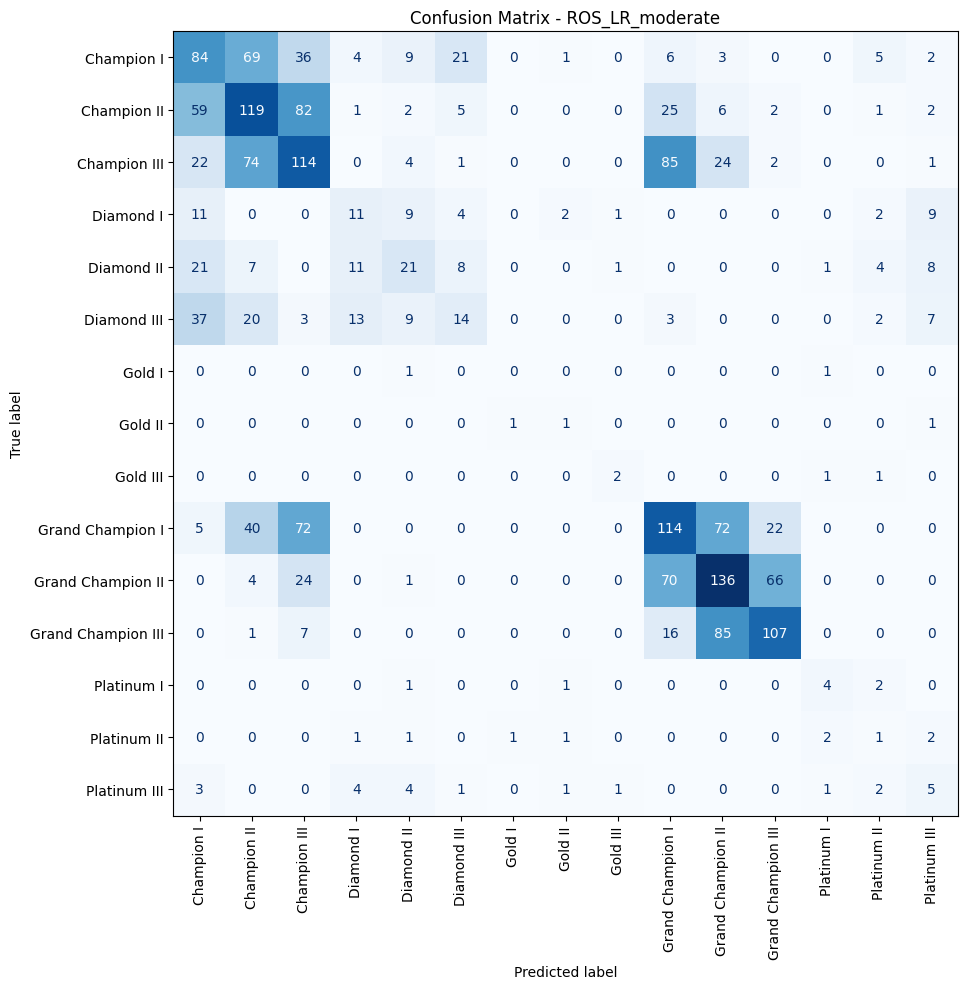

In [26]:
best_model_name = imbalance_results_df.iloc[0]["model"]
best_model = imbalance_models[best_model_name]

print("========================================")
print("Entrenamiento final en holdout")
print("========================================")
print(f"Mejor candidato por F1-macro CV: {best_model_name}")

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\nClassification report (holdout test):")
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax,
    colorbar=False
)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## Section 12 - Advanced Imbalance Improvements

Nuevas mejoras implementadas:
1. Evaluacion ordinal (errores adyacentes vs lejanos).
2. Pipeline SMOTENC-friendly para variables categoricas.
3. RandomizedSearchCV ligero sobre top candidatos.
4. Calibracion de probabilidades + ajuste de umbrales por clase.

In [27]:
import re
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score

def rank_to_ordinal(rank: str) -> int | None:
    if rank is None or pd.isna(rank):
        return None
    s = str(rank).strip()

    tier_map = {
        "Bronze": 0,
        "Silver": 1,
        "Gold": 2,
        "Platinum": 3,
        "Diamond": 4,
        "Champion": 5,
        "Grand Champion": 6,
        "Supersonic Legend": 7,
    }
    div_map = {"I": 0, "II": 1, "III": 2}

    if s == "Supersonic Legend":
        return tier_map[s] * 3 + 2

    m = re.match(r"^(Grand Champion|Champion|Diamond|Platinum|Gold|Silver|Bronze)\s+(I|II|III)$", s)
    if not m:
        return None

    tier, div = m.group(1), m.group(2)
    return tier_map[tier] * 3 + div_map[div]

def ordinal_distance_report(y_true: pd.Series, y_pred: pd.Series) -> pd.DataFrame:
    df_eval = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df_eval["true_ord"] = df_eval["y_true"].apply(rank_to_ordinal)
    df_eval["pred_ord"] = df_eval["y_pred"].apply(rank_to_ordinal)
    df_eval = df_eval.dropna(subset=["true_ord", "pred_ord"]).copy()
    df_eval["ord_dist"] = (df_eval["true_ord"] - df_eval["pred_ord"]).abs()

    total = len(df_eval)
    if total == 0:
        return pd.DataFrame()

    summary = pd.DataFrame({
        "metric": [
            "mean_abs_ordinal_error",
            "pct_exact",
            "pct_within_1",
            "pct_within_2",
        ],
        "value": [
            df_eval["ord_dist"].mean(),
            (df_eval["ord_dist"] == 0).mean(),
            (df_eval["ord_dist"] <= 1).mean(),
            (df_eval["ord_dist"] <= 2).mean(),
        ],
    })
    return summary

In [28]:
# 1) Evaluacion ordinal del mejor modelo actual
ordinal_summary_current = ordinal_distance_report(y_test, y_pred)

print("========================================")
print("Reporte ordinal - modelo actual")
print("========================================")
display(ordinal_summary_current)

# 2) Pipeline alternativo con SMOTENC-friendly (categoricas ordinal-encoded)
numeric_transformer_smotenc = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer_smotenc = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor_smotenc = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_smotenc, numeric_cols),
        ("cat", categorical_transformer_smotenc, categorical_cols),
    ]
)

n_num = len(numeric_cols)
n_cat = len(categorical_cols)
cat_idx = list(range(n_num, n_num + n_cat))

smotenc_strategy = build_smote_strategy(y_train, k_neighbors=3)
if n_cat > 0 and smotenc_strategy:
    smotenc_lr = ImbPipeline(steps=[
        ("preprocessor", preprocessor_smotenc),
        ("sampler", SMOTENC(
            categorical_features=cat_idx,
            sampling_strategy=smotenc_strategy,
            k_neighbors=3,
            random_state=42,
        )),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
    ])

    smotenc_scores = cross_validate(
        smotenc_lr,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    smotenc_row = {"model": "SMOTENC_LR_moderate"}
    for metric in scoring.keys():
        smotenc_row[f"{metric}_mean"] = smotenc_scores[f"test_{metric}"].mean()
        smotenc_row[f"{metric}_std"] = smotenc_scores[f"test_{metric}"].std()

    smotenc_results_df = pd.DataFrame([smotenc_row])
    print("\nSMOTENC candidate ready and evaluated:")
    display(smotenc_results_df)
else:
    smotenc_lr = None
    smotenc_results_df = pd.DataFrame()
    print("\n[WARN] SMOTENC no aplicado: no hay categoricas o no hay estrategia valida.")

Reporte ordinal - modelo actual


,metric,value
0,mean_abs_ordinal_error,0.9315
1,pct_exact,0.3665
2,pct_within_1,0.7925
3,pct_within_2,0.9420


C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas


SMOTENC candidate ready and evaluated:


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,SMOTENC_LR_moderate,0.363261,0.008749,0.251469,0.018542,0.361684,0.007709,0.250298,0.014601,0.272087,0.026801,0.267432,0.009736


In [29]:
# 3) Hyperparameter search ligero sobre top 3 candidatos por F1-macro
top3_names = imbalance_results_df.head(3)["model"].tolist()
print("Top 3 para tuning:", top3_names)

search_spaces = {
    "LR_class_weight_balanced": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "ROS_LR_moderate": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "SMOTE_LR_moderate": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "RF_class_weight_balanced_subsample": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "ROS_RF_moderate": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "SMOTE_RF_moderate": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "BalancedRandomForest": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
}

tuning_rows = []
best_tuned_estimators = {}

for name in top3_names:
    if name not in imbalance_models:
        continue
    if name not in search_spaces:
        continue

    base_model = imbalance_models[name]
    param_dist = search_spaces[name]

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=min(8, max(1, len(list(param_dist.values())[0]))),
        scoring="f1_macro",
        cv=3,
        random_state=42,
        n_jobs=1,
        verbose=0,
        refit=True,
    )

    print(f"Tuning: {name}")
    search.fit(X_train, y_train)
    best_tuned_estimators[name] = search.best_estimator_

    tuning_rows.append({
        "model": name,
        "best_cv_f1_macro": search.best_score_,
        "best_params": str(search.best_params_),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_cv_f1_macro", ascending=False)
print("\n========================================")
print("Resultados de tuning ligero")
print("========================================")
display(tuning_df)

Top 3 para tuning: ['ROS_LR_moderate', 'SMOTE_LR_moderate', 'LR_class_weight_balanced']
Tuning: ROS_LR_moderate
Tuning: SMOTE_LR_moderate
Tuning: LR_class_weight_balanced

Resultados de tuning ligero


,model,best_cv_f1_macro,best_params
1,SMOTE_LR_moderate,0.275450,{'classifier__C': 3.0}
0,ROS_LR_moderate,0.264087,{'classifier__C': 1.0}
2,LR_class_weight_balanced,0.263772,{'classifier__C': 3.0}


In [32]:
# 4) Calibracion + ajuste de umbrales por clase (sobre mejor tuned disponible)
import numpy as np

if not tuning_df.empty:
    chosen_name = tuning_df.iloc[0]["model"]
    chosen_model = best_tuned_estimators[chosen_name]
else:
    chosen_name = imbalance_results_df.iloc[0]["model"]
    chosen_model = imbalance_models[chosen_name]

print("Modelo elegido para calibracion:", chosen_name)

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
 )

# Calibracion robusta para esta version de sklearn (sin modo prefit).
calibrated_model = CalibratedClassifierCV(chosen_model, cv=3, method="sigmoid")
calibrated_model.fit(X_fit, y_fit)

cal_classes = calibrated_model.classes_
cal_proba = calibrated_model.predict_proba(X_cal)

def predict_with_class_multipliers(proba: np.ndarray, classes: np.ndarray, multipliers: dict) -> np.ndarray:
    adj = proba.copy()
    for i, c in enumerate(classes):
        adj[:, i] = adj[:, i] * multipliers.get(c, 1.0)
    idx = adj.argmax(axis=1)
    return classes[idx]

# Busqueda ligera de multiplicadores globales para clases minoritarias
counts_fit = y_fit.value_counts()
median_count = counts_fit.median()
minority_classes = set(counts_fit[counts_fit < median_count].index.tolist())

grid = [0.8, 0.9, 1.0, 1.1, 1.2]
best_f1 = -1.0
best_global_mult = 1.0

for g in grid:
    mult = {c: (g if c in minority_classes else 1.0) for c in cal_classes}
    pred = predict_with_class_multipliers(cal_proba, cal_classes, mult)
    score = f1_score(y_cal, pred, average="macro")
    if score > best_f1:
        best_f1 = score
        best_global_mult = g

best_multipliers = {c: (best_global_mult if c in minority_classes else 1.0) for c in cal_classes}
print(f"Mejor multiplicador global para clases minoritarias: {best_global_mult}")
print(f"F1-macro en calibracion con ajuste: {best_f1:.4f}")

# Evaluacion final en test (sin y con ajuste de umbrales)
test_proba = calibrated_model.predict_proba(X_test)
y_test_pred_cal = calibrated_model.predict(X_test)
y_test_pred_thr = predict_with_class_multipliers(test_proba, cal_classes, best_multipliers)

print("\n=== Holdout - calibrated (default argmax) ===")
print(classification_report(y_test, y_test_pred_cal, digits=4))

print("\n=== Holdout - calibrated + threshold multipliers ===")
print(classification_report(y_test, y_test_pred_thr, digits=4))

print("\n=== Reporte ordinal (threshold multipliers) ===")
display(ordinal_distance_report(y_test, y_test_pred_thr))

Modelo elegido para calibracion: SMOTE_LR_moderate
Mejor multiplicador global para clases minoritarias: 1.2
F1-macro en calibracion con ajuste: 0.1544

=== Holdout - calibrated (default argmax) ===
                    precision    recall  f1-score   support

        Champion I     0.1643    0.1458    0.1545       240
       Champion II     0.2349    0.3717    0.2879       304
      Champion III     0.2874    0.3823    0.3281       327
         Diamond I     0.2727    0.0612    0.1000        49
        Diamond II     0.0000    0.0000    0.0000        82
       Diamond III     0.0000    0.0000    0.0000       108
            Gold I     0.0000    0.0000    0.0000         2
           Gold II     0.0000    0.0000    0.0000         3
          Gold III     0.0000    0.0000    0.0000         4
  Grand Champion I     0.3311    0.3046    0.3173       325
 Grand Champion II     0.3526    0.4452    0.3935       301
Grand Champion III     0.5227    0.4259    0.4694       216
        Platinum I   

C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\callo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

,metric,value
0,mean_abs_ordinal_error,1.1415
1,pct_exact,0.3000
2,pct_within_1,0.7335
3,pct_within_2,0.8975


In [33]:
# 5) Experimento ordinal agrupado por tier (adyacencia de rangos)
def rank_to_tier(rank: str) -> str:
    if rank is None or pd.isna(rank):
        return "Unknown"
    s = str(rank).strip()
    if s == "Supersonic Legend":
        return "Supersonic Legend"
    m = re.match(r"^(Grand Champion|Champion|Diamond|Platinum|Gold|Silver|Bronze)\s+(I|II|III)$", s)
    if m:
        return m.group(1)
    return s

y_train_tier = y_train.apply(rank_to_tier)
y_test_tier = y_test.apply(rank_to_tier)

tier_ros_strategy = build_moderate_sampling_strategy(y_train_tier)
tier_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(sampling_strategy=tier_ros_strategy, random_state=42)),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

tier_cv_scores = cross_validate(
    tier_model,
    X_train,
    y_train_tier,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
    },
    n_jobs=1,
    return_train_score=False,
 )

print("========================================")
print("Tier-level experiment (ordinal grouping)")
print("========================================")
print(f"Tier CV f1_macro mean: {tier_cv_scores['test_f1_macro'].mean():.4f}")
print(f"Tier CV recall_macro mean: {tier_cv_scores['test_recall_macro'].mean():.4f}")

tier_model.fit(X_train, y_train_tier)
y_tier_pred = tier_model.predict(X_test)
print("\nTier holdout report:")
print(classification_report(y_test_tier, y_tier_pred, digits=4))

Tier-level experiment (ordinal grouping)
Tier CV f1_macro mean: 0.6059
Tier CV recall_macro mean: 0.6575

Tier holdout report:
                precision    recall  f1-score   support

      Champion     0.7239    0.7796    0.7507       871
       Diamond     0.6226    0.4142    0.4975       239
          Gold     0.4000    0.4444    0.4211         9
Grand Champion     0.8262    0.8076    0.8168       842
      Platinum     0.2714    0.4872    0.3486        39

      accuracy                         0.7405      2000
     macro avg     0.5688    0.5866    0.5669      2000
  weighted avg     0.7446    0.7405    0.7389      2000



## Section 13 - Initial vs Current Comparison

Comparacion directa entre:
1. Baseline inicial (sin metodos de desbalance).
2. Mejor modelo exact-rank actual (con desbalance).
3. Modelo por tiers (opcional para produccion orientada a robustez).

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---- Construir mejor baseline inicial (sin mejoras de desbalance) ----
baseline_only = baseline_combined_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).copy()
baseline_best_name = baseline_only.iloc[0]["model"]

def get_baseline_model_by_name(name: str):
    if name == "Dummy_most_frequent":
        return dummy_model
    if "model" in results_df.columns and name in set(results_df["model"]):
        clf = models[name]
        return Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    if "model" in ensemble_results_df.columns and name in set(ensemble_results_df["model"]):
        clf = ensemble_models[name]
        return Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    raise KeyError(f"No se pudo mapear modelo baseline: {name}")

baseline_best_model = get_baseline_model_by_name(baseline_best_name)
baseline_best_model.fit(X_train, y_train)
y_pred_baseline = baseline_best_model.predict(X_test)

# ---- Mejor exact-rank actual (con desbalance) ----
exact_best_name = imbalance_results_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).iloc[0]["model"]
exact_best_model = imbalance_models[exact_best_name]
exact_best_model.fit(X_train, y_train)
y_pred_exact_current = exact_best_model.predict(X_test)

# ---- Tier model actual ----
tier_model.fit(X_train, y_train_tier)
y_pred_tier_current = tier_model.predict(X_test)

comparison_rows = [
    {
        "scenario": "Initial baseline (exact rank)",
        "model": baseline_best_name,
        "task": "exact_rank",
        "cv_f1_macro": float(baseline_only.iloc[0]["f1_macro_mean"]),
        "cv_recall_macro": float(baseline_only.iloc[0]["recall_macro_mean"]),
        "holdout_accuracy": accuracy_score(y_test, y_pred_baseline),
        "holdout_f1_macro": f1_score(y_test, y_pred_baseline, average="macro"),
        "holdout_recall_macro": recall_score(y_test, y_pred_baseline, average="macro"),
    },
    {
        "scenario": "Current improved (exact rank)",
        "model": exact_best_name,
        "task": "exact_rank",
        "cv_f1_macro": float(imbalance_results_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).iloc[0]["f1_macro_mean"]),
        "cv_recall_macro": float(imbalance_results_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).iloc[0]["recall_macro_mean"]),
        "holdout_accuracy": accuracy_score(y_test, y_pred_exact_current),
        "holdout_f1_macro": f1_score(y_test, y_pred_exact_current, average="macro"),
        "holdout_recall_macro": recall_score(y_test, y_pred_exact_current, average="macro"),
    },
    {
        "scenario": "Current improved (tier rank)",
        "model": "Tier_ROS_LR",
        "task": "tier_rank",
        "cv_f1_macro": float(tier_cv_scores["test_f1_macro"].mean()),
        "cv_recall_macro": float(tier_cv_scores["test_recall_macro"].mean()),
        "holdout_accuracy": accuracy_score(y_test_tier, y_pred_tier_current),
        "holdout_f1_macro": f1_score(y_test_tier, y_pred_tier_current, average="macro"),
        "holdout_recall_macro": recall_score(y_test_tier, y_pred_tier_current, average="macro"),
    },
]

metrics_comparison_df = pd.DataFrame(comparison_rows)

# Delta vs baseline inicial
baseline_ref = metrics_comparison_df.iloc[0]
for col in ["cv_f1_macro", "cv_recall_macro", "holdout_accuracy", "holdout_f1_macro", "holdout_recall_macro"]:
    metrics_comparison_df[f"delta_vs_initial_{col}"] = metrics_comparison_df[col] - baseline_ref[col]

print("========================================")
print("Initial vs Current comparison")
print("========================================")
display(metrics_comparison_df)

Initial vs Current comparison


,scenario,model,task,cv_f1_macro,cv_recall_macro,holdout_accuracy,holdout_f1_macro,holdout_recall_macro,delta_vs_initial_cv_f1_macro,delta_vs_initial_cv_recall_macro,delta_vs_initial_holdout_accuracy,delta_vs_initial_holdout_f1_macro,delta_vs_initial_holdout_recall_macro
0,Initial baseline (exact rank),LogisticRegression,exact_rank,0.293374,0.288205,0.3755,0.327937,0.317934,0.000000,0.000000,0.000,0.000000,0.000000
1,Current improved (exact rank),ROS_LR_moderate,exact_rank,0.275277,0.298532,0.3665,0.292923,0.311331,-0.018097,0.010327,-0.009,-0.035014,-0.006603
2,Current improved (tier rank),Tier_ROS_LR,tier_rank,0.605892,0.657454,0.7405,0.566934,0.586603,0.312519,0.369249,0.365,0.238997,0.268668


## Section 14 - Production Selector

Seleccion automatica del modelo segun objetivo de negocio:
- `exact_rank`: usar el mejor modelo exacto mejorado.
- `tier_rank`: usar el modelo por tiers (mas robusto).

In [35]:
# Cambia este valor segun tu objetivo final: "exact_rank" o "tier_rank"
DEPLOY_OBJECTIVE = "exact_rank"

if DEPLOY_OBJECTIVE == "exact_rank":
    production_model = exact_best_model
    production_task = "exact_rank"
    production_label_transform = lambda y: y
    production_inverse_transform = lambda y: y
elif DEPLOY_OBJECTIVE == "tier_rank":
    production_model = tier_model
    production_task = "tier_rank"
    production_label_transform = rank_to_tier
    production_inverse_transform = lambda y: y
else:
    raise ValueError("DEPLOY_OBJECTIVE debe ser 'exact_rank' o 'tier_rank'")

print("========================================")
print("Production selector")
print("========================================")
print(f"Objective: {DEPLOY_OBJECTIVE}")
print(f"Task: {production_task}")

if production_task == "exact_rank":
    final_pred = production_model.predict(X_test)
    print("\nProduction holdout report (exact rank):")
    print(classification_report(y_test, final_pred, digits=4))
else:
    final_pred = production_model.predict(X_test)
    print("\nProduction holdout report (tier rank):")
    print(classification_report(y_test_tier, final_pred, digits=4))

def predict_production(X_new: pd.DataFrame) -> pd.Series:
    y_hat = production_model.predict(X_new)
    return pd.Series(y_hat, index=X_new.index, name="prediction")

print("\nFuncion disponible: predict_production(X_new)")

Production selector
Objective: exact_rank
Task: exact_rank

Production holdout report (exact rank):
                    precision    recall  f1-score   support

        Champion I     0.3471    0.3500    0.3485       240
       Champion II     0.3563    0.3914    0.3730       304
      Champion III     0.3373    0.3486    0.3429       327
         Diamond I     0.2444    0.2245    0.2340        49
        Diamond II     0.3387    0.2561    0.2917        82
       Diamond III     0.2593    0.1296    0.1728       108
            Gold I     0.0000    0.0000    0.0000         2
           Gold II     0.1429    0.3333    0.2000         3
          Gold III     0.4000    0.5000    0.4444         4
  Grand Champion I     0.3574    0.3508    0.3540       325
 Grand Champion II     0.4172    0.4518    0.4338       301
Grand Champion III     0.5377    0.4954    0.5157       216
        Platinum I     0.4000    0.5000    0.4444         8
       Platinum II     0.0500    0.1111    0.0690         9

## Section 15 - Grouped Target (Ignore Divisions)

Target agrupado por rango principal (sin I/II/III):
- Champion
- Diamond
- Gold
- Grand Champion
- Platinum

Objetivo: verificar si al ignorar divisiones mejora estabilidad y calidad global.

In [36]:
# Reusar helper rank_to_tier definido en secciones anteriores
y_group = y.apply(rank_to_tier)

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X,
    y_group,
    test_size=0.2,
    random_state=42,
    stratify=y_group,
 )

group_scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}

cv_group = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

group_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

group_ros_strategy = build_moderate_sampling_strategy(y_train_g)
group_ros = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(sampling_strategy=group_ros_strategy, random_state=42)),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

group_models = {
    "Grouped_Baseline_LR": group_baseline,
    "Grouped_ROS_LR": group_ros,
}

group_rows = []
for name, model in group_models.items():
    scores = cross_validate(
        model,
        X_train_g,
        y_train_g,
        cv=cv_group,
        scoring=group_scoring,
        n_jobs=1,
        return_train_score=False,
    )
    row = {"model": name}
    for metric in group_scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    group_rows.append(row)

group_results_df = pd.DataFrame(group_rows).sort_values("f1_macro_mean", ascending=False)
display(group_results_df)

best_group_model_name = group_results_df.iloc[0]["model"]
best_group_model = group_models[best_group_model_name]
best_group_model.fit(X_train_g, y_train_g)
y_pred_group = best_group_model.predict(X_test_g)

print("\nBest grouped model:", best_group_model_name)
print("Grouped holdout report:")
print(classification_report(y_test_g, y_pred_group, digits=4))

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std
0,Grouped_Baseline_LR,0.764787,0.005917,0.625517,0.019081,0.763157,0.005916,0.660132,0.016107,0.611579,0.032437
1,Grouped_ROS_LR,0.750532,0.008165,0.591210,0.019620,0.749958,0.008869,0.581503,0.019918,0.646738,0.038103



Best grouped model: Grouped_Baseline_LR
Grouped holdout report:
                precision    recall  f1-score   support

      Champion     0.7301    0.7669    0.7480       871
       Diamond     0.6415    0.5690    0.6031       239
          Gold     0.6364    0.7778    0.7000         9
Grand Champion     0.8189    0.8219    0.8204       842
      Platinum     0.7059    0.3077    0.4286        39

      accuracy                         0.7575      2000
     macro avg     0.7065    0.6487    0.6600      2000
  weighted avg     0.7560    0.7575    0.7547      2000



In [37]:
grouped_row = {
    "scenario": "Current improved (grouped, no divisions)",
    "model": best_group_model_name,
    "task": "grouped_rank",
    "cv_f1_macro": float(group_results_df.iloc[0]["f1_macro_mean"]),
    "cv_recall_macro": float(group_results_df.iloc[0]["recall_macro_mean"]),
    "holdout_accuracy": accuracy_score(y_test_g, y_pred_group),
    "holdout_f1_macro": f1_score(y_test_g, y_pred_group, average="macro"),
    "holdout_recall_macro": recall_score(y_test_g, y_pred_group, average="macro"),
}

metrics_comparison_plus_grouped_df = pd.concat(
    [metrics_comparison_df, pd.DataFrame([grouped_row])],
    ignore_index=True,
    sort=False,
)

baseline_ref = metrics_comparison_plus_grouped_df.iloc[0]
for col in ["cv_f1_macro", "cv_recall_macro", "holdout_accuracy", "holdout_f1_macro", "holdout_recall_macro"]:
    metrics_comparison_plus_grouped_df[f"delta_vs_initial_{col}"] = (
        metrics_comparison_plus_grouped_df[col] - baseline_ref[col]
    )

print("========================================")
print("Comparison updated with grouped (no divisions)")
print("========================================")
display(metrics_comparison_plus_grouped_df)

Comparison updated with grouped (no divisions)


,scenario,model,task,cv_f1_macro,cv_recall_macro,holdout_accuracy,holdout_f1_macro,holdout_recall_macro,delta_vs_initial_cv_f1_macro,delta_vs_initial_cv_recall_macro,delta_vs_initial_holdout_accuracy,delta_vs_initial_holdout_f1_macro,delta_vs_initial_holdout_recall_macro
0,Initial baseline (exact rank),LogisticRegression,exact_rank,0.293374,0.288205,0.3755,0.327937,0.317934,0.000000,0.000000,0.000,0.000000,0.000000
1,Current improved (exact rank),ROS_LR_moderate,exact_rank,0.275277,0.298532,0.3665,0.292923,0.311331,-0.018097,0.010327,-0.009,-0.035014,-0.006603
2,Current improved (tier rank),Tier_ROS_LR,tier_rank,0.605892,0.657454,0.7405,0.566934,0.586603,0.312519,0.369249,0.365,0.238997,0.268668
3,"Current improved (grouped, no divisions)",Grouped_Baseline_LR,grouped_rank,0.625517,0.611579,0.7575,0.660021,0.648659,0.332143,0.323373,0.382,0.332084,0.330725


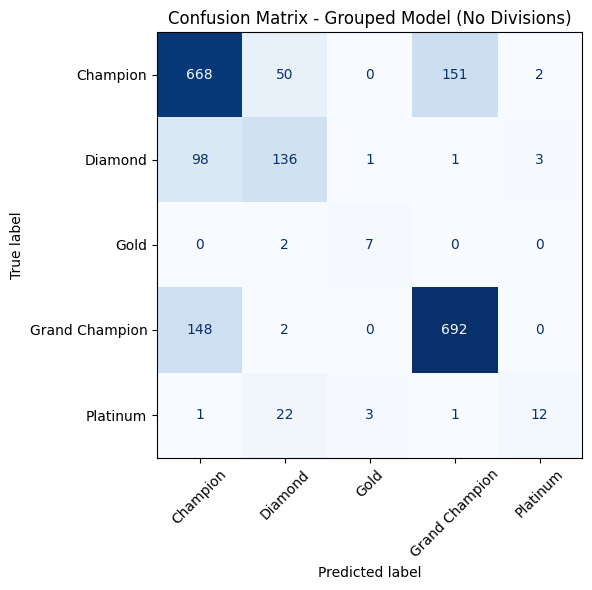

In [38]:
# Confusion matrix - grouped model (sin divisiones)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

if "y_test_g" not in globals() or "y_pred_group" not in globals():
    raise NameError("Primero ejecuta la celda de Section 15 para generar y_test_g y y_pred_group.")

group_labels = sorted(pd.Series(y_test_g).unique().tolist())

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_g,
    y_pred_group,
    labels=group_labels,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax,
 )
ax.set_title("Confusion Matrix - Grouped Model (No Divisions)")
plt.tight_layout()
plt.show()

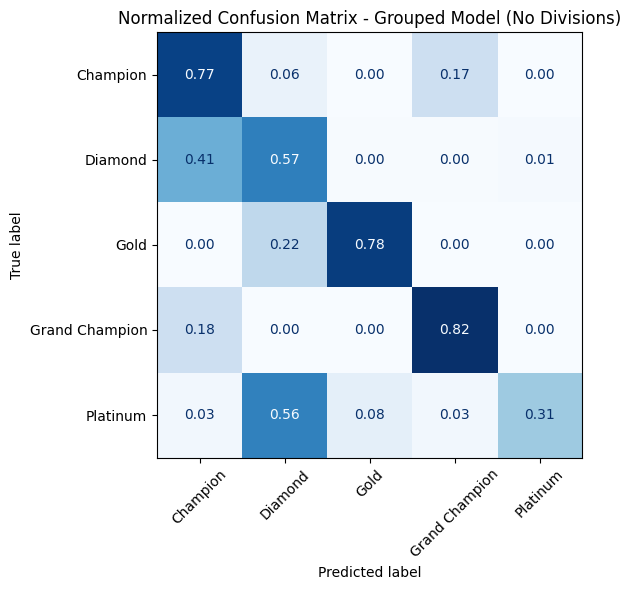

In [42]:
# Confusion matrix normalizada - grouped model (porcentaje por clase real)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

if "y_test_g" not in globals() or "y_pred_group" not in globals():
    raise NameError("Primero ejecuta la celda de Section 15 para generar y_test_g y y_pred_group.")

group_labels = sorted(pd.Series(y_test_g).unique().tolist())

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_g,
    y_pred_group,
    labels=group_labels,
    normalize="true",
    xticks_rotation=45,
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=ax,
 )
ax.set_title("Normalized Confusion Matrix - Grouped Model (No Divisions)")
plt.tight_layout()
plt.show()